In [3]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import kagglehub

import tensorflow as tf
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


In [4]:
path = kagglehub.dataset_download('wish096/realvsfake-81k-by-wish')
print('Dataset Root:', path)

100%|██████████| 4.93G/4.93G [01:01<00:00, 85.8MB/s]

Extracting files...


Dataset Root: /root/.cache/kagglehub/datasets/wish096/realvsfake-81k-by-wish/versions/3


In [5]:
# ================================
# 🔍 FIND REAL / FAKE FOLDERS
# ================================
def find_folder(root, target):
    for dirpath, dirnames, filenames in os.walk(root):
        if target in dirnames:
            return os.path.join(dirpath, target)
    return None

real_path = find_folder(path, 'Real')
fake_path = find_folder(path, 'Fake')

print('Real Path:', real_path)
print('Fake Path:', fake_path)
print('Real images count:', len(os.listdir(real_path)))
print('Fake images count:', len(os.listdir(fake_path)))

Real Path: /root/.cache/kagglehub/datasets/wish096/realvsfake-81k-by-wish/versions/3/RealVsFake/RealVsFake/Real
Fake Path: /root/.cache/kagglehub/datasets/wish096/realvsfake-81k-by-wish/versions/3/RealVsFake/RealVsFake/Fake
Real images count: 81000
Fake images count: 80972


In [6]:
import shutil, random

TRAIN, TEST = 5000, 2000
STAGED_DIR = '/tmp/data'


if os.path.exists(STAGED_DIR):
    shutil.rmtree(STAGED_DIR)


exts = ('.jpg', '.jpeg', '.png', '.webp')
real = [os.path.join(real_path, f) for f in os.listdir(real_path) if f.endswith(exts)]
fake = [os.path.join(fake_path, f) for f in os.listdir(fake_path) if f.endswith(exts)]

random.shuffle(real)
random.shuffle(fake)


real_train, real_test = real[:TRAIN], real[TRAIN:TRAIN+TEST]
fake_train, fake_test = fake[:TRAIN], fake[TRAIN:TRAIN+TEST]


data = {
    'train/Real': real_train,
    'train/Fake': fake_train,
    'test/Real' : real_test,
    'test/Fake' : fake_test,
}
for k, files in data.items():
    path = os.path.join(STAGED_DIR, k)
    os.makedirs(path, exist_ok=True)
    for f in files:
        os.symlink(f, os.path.join(path, os.path.basename(f)))

train_dir = STAGED_DIR + '/train'
test_dir  = STAGED_DIR + '/test'

print("Done ✅")


Done ✅


In [7]:
# ================================
# 🖼️ LOAD SAMPLE IMAGES
# ================================
def load_images(folder, num_samples=5):
    images = []
    files = os.listdir(folder)
    files = random.sample(files, min(num_samples, len(files)))
    for file in files:
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append(img)
    return images

real_images = load_images(real_path, 5)
fake_images = load_images(fake_path, 5)

/tmp/ipykernel_12742/1241702660.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12742/1241702660.py:19: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


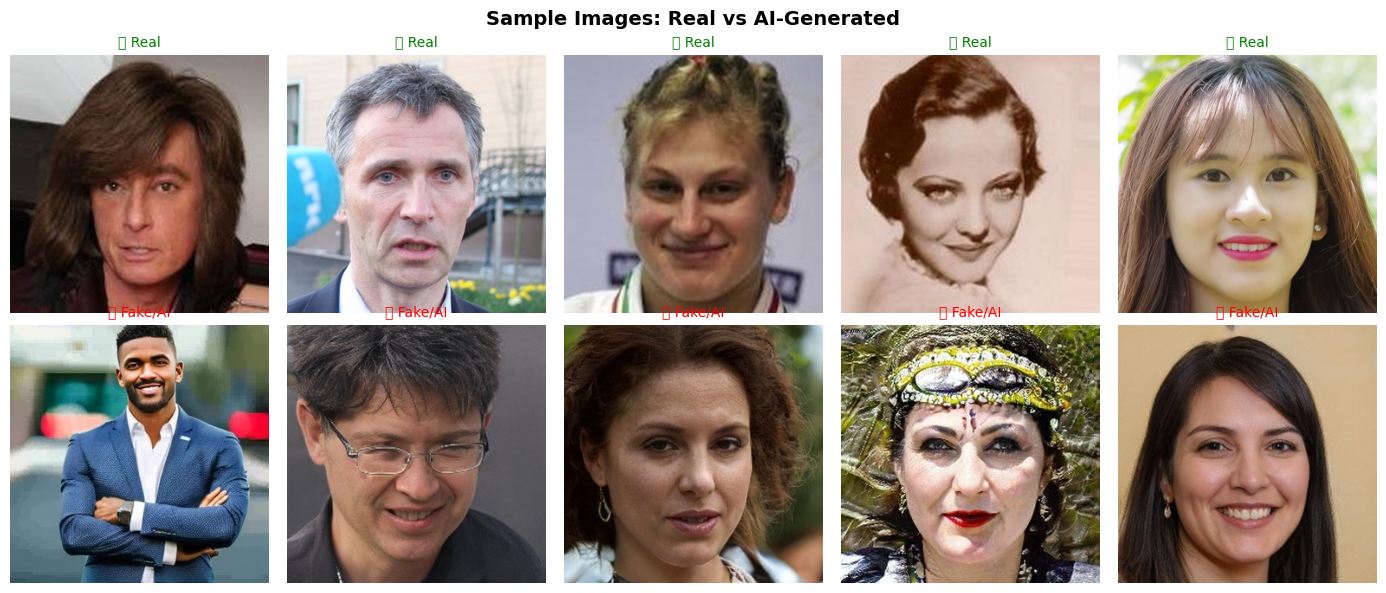

In [8]:
# ================================
# 📊 VISUALIZE SAMPLES
# ================================
plt.figure(figsize=(14, 6))

for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(real_images[i])
    plt.title('✅ Real', fontsize=10, color='green')
    plt.axis('off')

for i in range(5):
    plt.subplot(2, 5, i + 6)
    plt.imshow(fake_images[i])
    plt.title('🤖 Fake/AI', fontsize=10, color='red')
    plt.axis('off')

plt.suptitle('Sample Images: Real vs AI-Generated', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ================================
# ⚙️ CONFIGURATION
# ================================
IMG_SIZE, BATCH_SIZE, EPOCHS = 224, 32, 20
import pathlib
dataset_root = str(pathlib.Path(real_path).parent)
print('Dataset root:', dataset_root)

Dataset root: /root/.cache/kagglehub/datasets/wish096/realvsfake-81k-by-wish/versions/3/RealVsFake/RealVsFake


In [10]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True
).flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 10000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


/tmp/ipykernel_12742/3612294822.py:16: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12742/3612294822.py:16: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


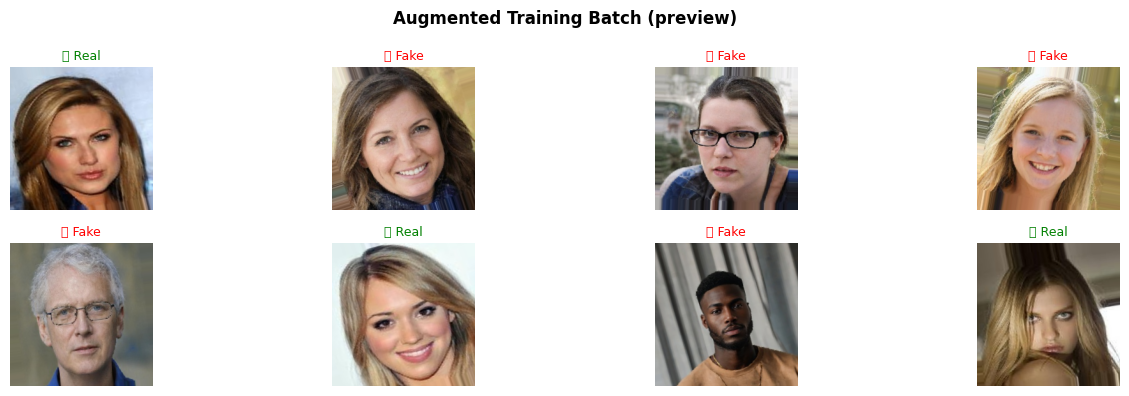

In [11]:
# ================================
# 🔍 PREVIEW AUGMENTED BATCH
# ================================
x_batch, y_batch = next(train_gen)

plt.figure(figsize=(14, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(x_batch[i])
    label = '✅ Real' if y_batch[i] == 1 else '🤖 Fake'
    color = 'green'  if y_batch[i] == 1 else 'red'
    plt.title(label, fontsize=9, color=color)
    plt.axis('off')

plt.suptitle('Augmented Training Batch (preview)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
base = MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3),
                   include_top=False, weights='imagenet')
base.trainable = False

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(base.input, out)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [14]:
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[
    EarlyStopping(
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        'best_model.keras',
        save_best_only=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        verbose=1
    )
]
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 684s 2s/step - accuracy: 0.7377 - loss: 0.5223 - val_accuracy: 0.7990 - val_loss: 0.4401 - learning_rate: 1.0000e-04
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 670s 2s/step - accuracy: 0.7958 - loss: 0.4303 - val_accuracy: 0.8105 - val_loss: 0.4117 - learning_rate: 1.0000e-04
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 668s 2s/step - accuracy: 0.8198 - loss: 0.3961 - val_accuracy: 0.8380 - val_loss: 0.3714 - learning_rate: 1.0000e-04
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 676s 2s/step - accuracy: 0.8288 - loss: 0.3726 - val_accuracy: 0.8300 - val_loss: 0.3677 - learning_rate: 1.0000e-04
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 668s 2s/step - accuracy: 0.8378 - loss: 0.3589 - val_accuracy: 0.8625 - val_loss: 0.3234 - learning_rate: 1.0000e-04
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 665s 2s/step - accuracy: 0.8480 - loss: 0.3439 - val_accuracy: 0.8525 - val_loss: 0.3277 - learning_rate: 1.0000e-04
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 675s 2s/step - acc

In [16]:
base.trainable = True

for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=[
        EarlyStopping(
            patience=3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 851s 3s/step - accuracy: 0.8522 - loss: 0.3265 - val_accuracy: 0.8025 - val_loss: 0.5218
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 820s 3s/step - accuracy: 0.8720 - loss: 0.2871 - val_accuracy: 0.8535 - val_loss: 0.3514
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 821s 3s/step - accuracy: 0.8908 - loss: 0.2513 - val_accuracy: 0.8650 - val_loss: 0.3204
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 807s 3s/step - accuracy: 0.8966 - loss: 0.2357 - val_accuracy: 0.8810 - val_loss: 0.2827
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 827s 3s/step - accuracy: 0.9121 - loss: 0.2080 - val_accuracy: 0.9135 - val_loss: 0.2055


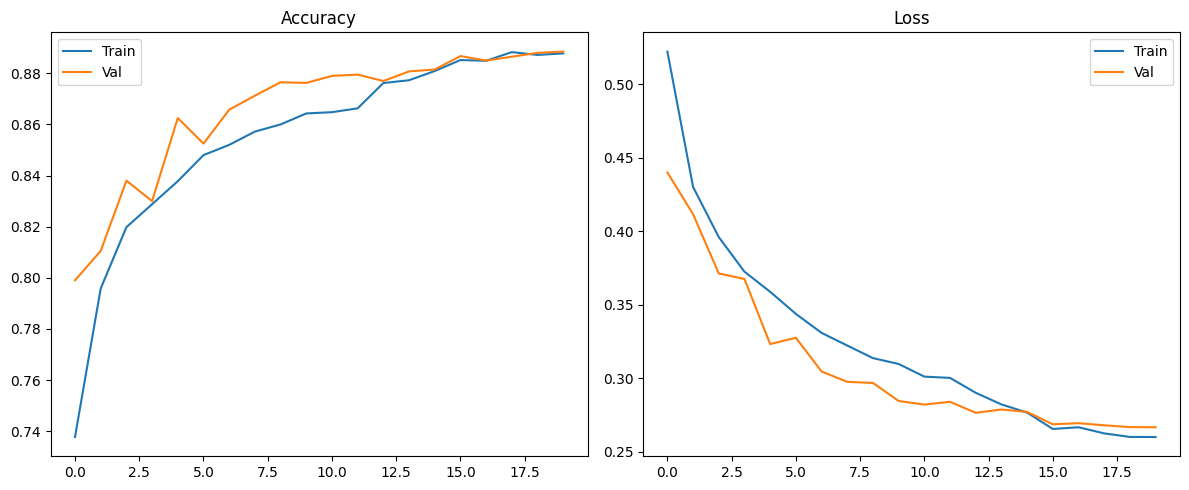

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Val'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Val'])

plt.tight_layout()
plt.show()

In [18]:
# ================================
# 📊 EVALUATE ON VALIDATION SET
# ================================
loss, acc = model.evaluate(val_gen, verbose=0)

print(f'Loss: {loss:.4f}')
print(f'Accuracy: {acc*100:.2f}%')

Loss: 0.2055
Accuracy: 91.35%


125/125 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step


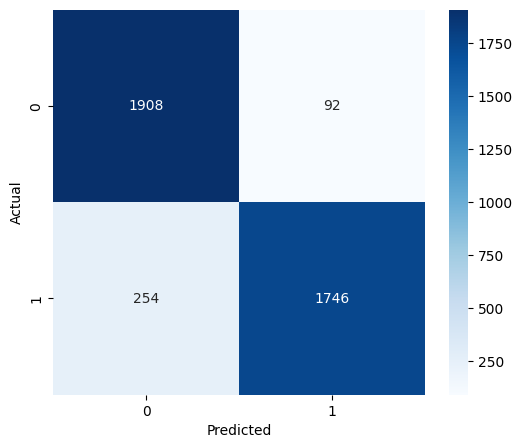

TP: 1746 | TN: 1908
FP: 92 | FN: 254


In [19]:
y_true = val_gen.classes
y_pred = (model.predict(val_gen) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
tn, fp, fn, tp = cm.ravel()
print("TP:", tp, "| TN:", tn)
print("FP:", fp, "| FN:", fn)

In [20]:
# ================================
# 📊 PRECISION / RECALL / F1
# ================================
print('Classification Report')
print('=' * 50)
print(classification_report(y_true, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.95      0.92      2000
           1       0.95      0.87      0.91      2000

    accuracy                           0.91      4000
   macro avg       0.92      0.91      0.91      4000
weighted avg       0.92      0.91      0.91      4000



In [21]:
def predict_image(img_src, model, size=224):
    if isinstance(img_src, str):
        img = cv2.cvtColor(cv2.imread(img_src), cv2.COLOR_BGR2RGB)
    else:
        img = img_src.copy()
    img = cv2.resize(img, (size, size)) / 255.0
    img = np.expand_dims(img, 0)
    prob = model.predict(img, verbose=0)[0][0]
    if prob > 0.5:
        return {'label': 'Real', 'confidence': prob * 100}
    else:
        return {'label': 'Fake', 'confidence': (1 - prob) * 100}

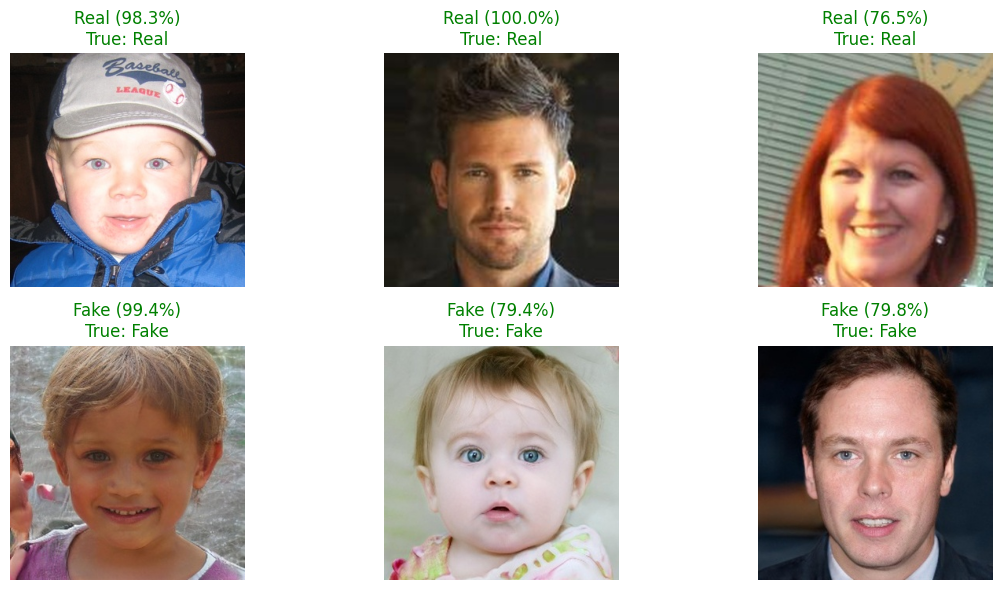

In [22]:
def visualize_predictions(image_paths, true_labels, model):
    plt.figure(figsize=(12, 6))
    for i in range(6):
        img = cv2.imread(image_paths[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        result = predict_image(image_paths[i], model)
        pred = result['label']
        conf = result['confidence']
        correct = (pred == true_labels[i])
        color = 'green' if correct else 'red'
        title = f"{pred} ({conf:.1f}%)\nTrue: {true_labels[i]}"
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(title, color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
real_files = [os.path.join(real_path, f) for f in os.listdir(real_path)[:3]]
fake_files = [os.path.join(fake_path, f) for f in os.listdir(fake_path)[:3]]
paths = real_files + fake_files
labels = ['Real']*3 + ['Fake']*3
visualize_predictions(paths, labels, model)

In [23]:
# ================================
# 💾 SAVE FINAL MODEL
# ================================
model.save('real_vs_fake_detector.keras')
print('✅ Model saved → real_vs_fake_detector.keras')
print()
print('To load later:')
print('  from tensorflow import keras')
print('  model = keras.models.load_model("real_vs_fake_detector.keras")')

✅ Model saved → real_vs_fake_detector.keras

To load later:
  from tensorflow import keras
  model = keras.models.load_model("real_vs_fake_detector.keras")


In [24]:
import gradio as gr
import numpy as np

def predict_ui(img):
    if img is None:
        return "No image", {}

    result = predict_image(np.array(img), model)

    prob = result['confidence']
    label = result['label']

    scores = {
        'Real': prob if label == 'Real' else 100 - prob,
        'Fake': prob if label == 'Fake' else 100 - prob
    }

    return f"{label} ({prob:.1f}%)", scores


with gr.Blocks() as demo:
    gr.Markdown("# Real vs Fake Detector")

    img = gr.Image(type="pil")
    btn = gr.Button("Predict")

    out_text = gr.Textbox()
    out_label = gr.Label()

    btn.click(predict_ui, img, [out_text, out_label])

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e38f1ec4fb9656cbb1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
